# **Preprocessing & Dimensionality Reduction**

## **Import Libraries**

In [33]:
import os
import sys

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import RobustScaler

from sklearn.decomposition import PCA


## **Load Cleaned Dataset and Quick Overview**

In [34]:
# Add src to path
sys.path.append(os.path.abspath("../"))
from src.data.load_data import load_cleaned_data

df = load_cleaned_data()

df.head()

,Limit_Bal,Gender,Education,Marriage,Age,RPay_stat_sep,RPay_stat_aug,RPay_stat_jul,RPay_stat_jun,RPay_stat_may,...,Bill_amt_jun,Bill_amt_may,Bill_amt_apr,Pay_amt_sep,Pay_amt_aug,Pay_amt_jul,Pay_amt_jun,Pay_amt_may,Pay_amt_apr,Default_Payment
0,20000,2,2,1,24,2,2,-1,-1,-2,...,0,0,0,0,689,0,0,0,0,1
1,120000,2,2,2,26,-1,2,0,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,2,2,2,34,0,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,50000,2,2,1,37,0,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,50000,1,2,1,57,-1,0,-1,0,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


## **Separate Features and Target**

In [35]:
X = df.drop('Default_Payment', axis=1)

y = df['Default_Payment']

## **Train/Test Split**

In [36]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

### **Why use `stratify=y`?**

The dataset contains class imbalance, meaning some classes appear more frequently than others.

Using `stratify=y` ensures that both the training and testing sets maintain the same class distribution as the original dataset. This helps the model learn and evaluate fairly without bias toward the majority class.

## **Feature Scaling**

In [37]:
# Scale features using RobustScaler
scaler = RobustScaler()


#Fit on Training Data Only
X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

# **Dimensionality Reduction using PCA**

In [38]:
pca = PCA()

X_train_pca = pca.fit_transform(X_train_scaled)

X_test_pca = pca.transform(X_test_scaled)

## **Explained Variance Analysis**

In [39]:
cumulative_variance = np.cumsum(
    pca.explained_variance_ratio_
)

### **Plot Explained Variance**

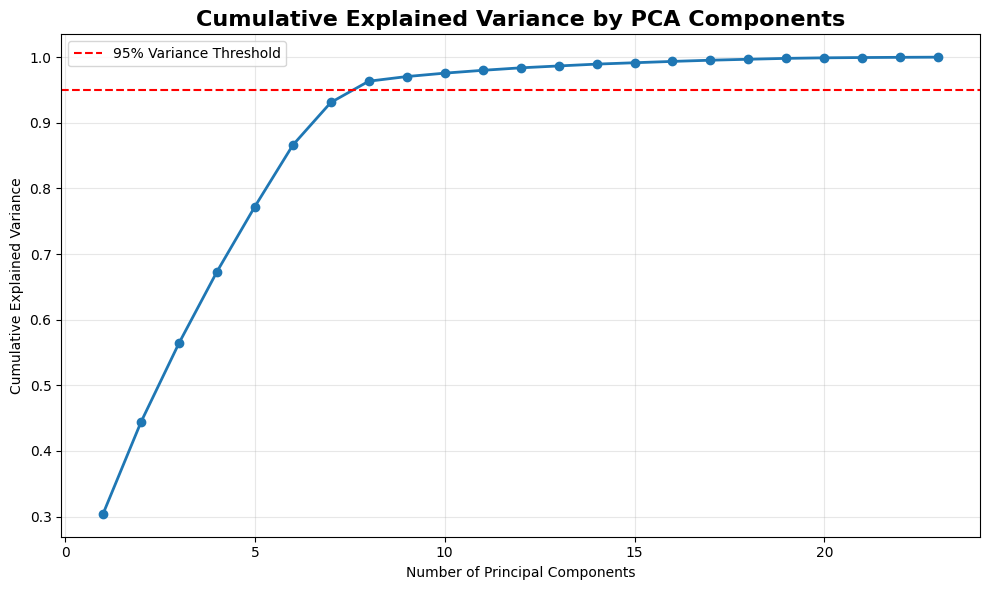

In [40]:
plt.figure(figsize=(10,6))

plt.plot(
    range(1, len(cumulative_variance)+1),
    cumulative_variance,
    marker='o',
    linewidth=2
)

plt.axhline(
    y=0.95,
    color='red',
    linestyle='--',
    label='95% Variance Threshold'
)

plt.title(
    'Cumulative Explained Variance by PCA Components',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

## **Select Optimal Components**

### **Find Optimal Components**

In [41]:
optimal_components = np.argmax( cumulative_variance >= 0.95) + 1

print(f'Optimal Number of Components: {optimal_components}')

Optimal Number of Components: 8


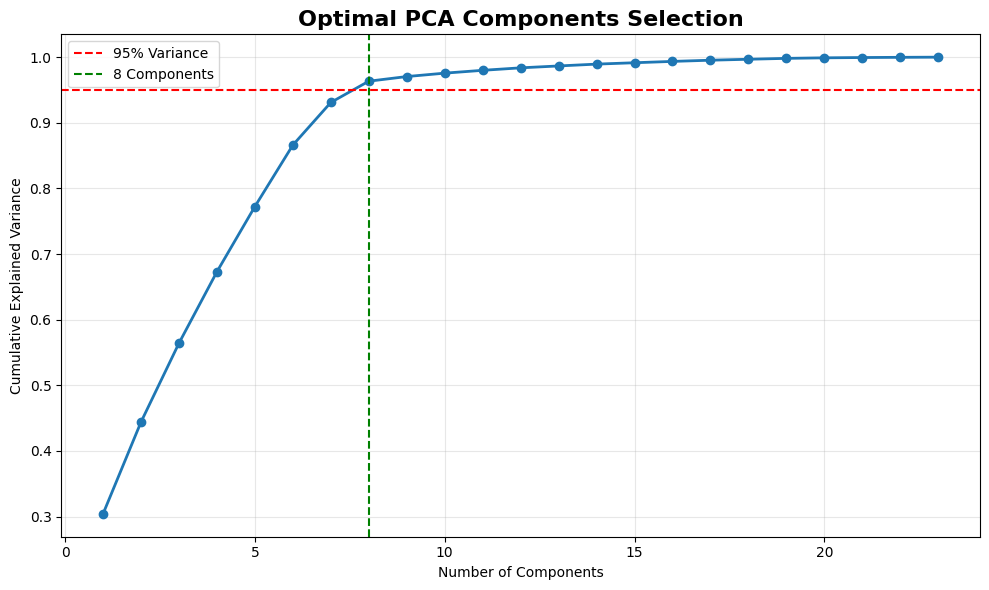

In [42]:
plt.figure(figsize=(10,6))

plt.plot(
    range(1, len(cumulative_variance)+1),
    cumulative_variance,
    marker='o',
    linewidth=2
)

plt.axhline(
    y=0.95,
    color='red',
    linestyle='--',
    label='95% Variance'
)

plt.axvline(
    x=optimal_components,
    color='green',
    linestyle='--',
    label=f'{optimal_components} Components'
)

plt.title(
    'Optimal PCA Components Selection',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

## **Apply Final PCA**

In [43]:
pca = PCA(n_components=optimal_components)

X_train_pca = pca.fit_transform(X_train_scaled)

X_test_pca = pca.transform(X_test_scaled)

### **Final Shape Comparison**

In [44]:
shape_comparison = pd.DataFrame({
    'Stage': ['Before PCA', 'After PCA'],
    
    'Rows': [X_train_scaled.shape[0], X_train_pca.shape[0]],
    
    'Features': [X_train_scaled.shape[1], X_train_pca.shape[1]]
})

shape_comparison

,Stage,Rows,Features
0,Before PCA,24000,23
1,After PCA,24000,8


## **Dimensionality Reduction Percentage**

In [45]:
reduction_percentage = ( 1 - ( X_train_pca.shape[1] / X_train_scaled.shape[1] )) * 100

print(f'Dimensionality Reduced By: {reduction_percentage:.2f}%')

Dimensionality Reduced By: 65.22%


### **PCA Variance Table**

In [46]:
pca_variance_df = pd.DataFrame({
    'Principal Component': [
        f'PC{i+1}'
        for i in range(len(pca.explained_variance_ratio_))
    ],
    
    'Explained Variance Ratio':
    pca.explained_variance_ratio_,
    
    'Cumulative Variance':
    np.cumsum(pca.explained_variance_ratio_)
})

pca_variance_df.head(10)

,Principal Component,Explained Variance Ratio,Cumulative Variance
0,PC1,0.304140,0.304140
1,PC2,0.139942,0.444082
2,PC3,0.120126,0.564208
3,PC4,0.108850,0.673057
4,PC5,0.099350,0.772407
5,PC6,0.093654,0.866061
6,PC7,0.064942,0.931003
7,PC8,0.032383,0.963386


### **PCA Projection Visualization**

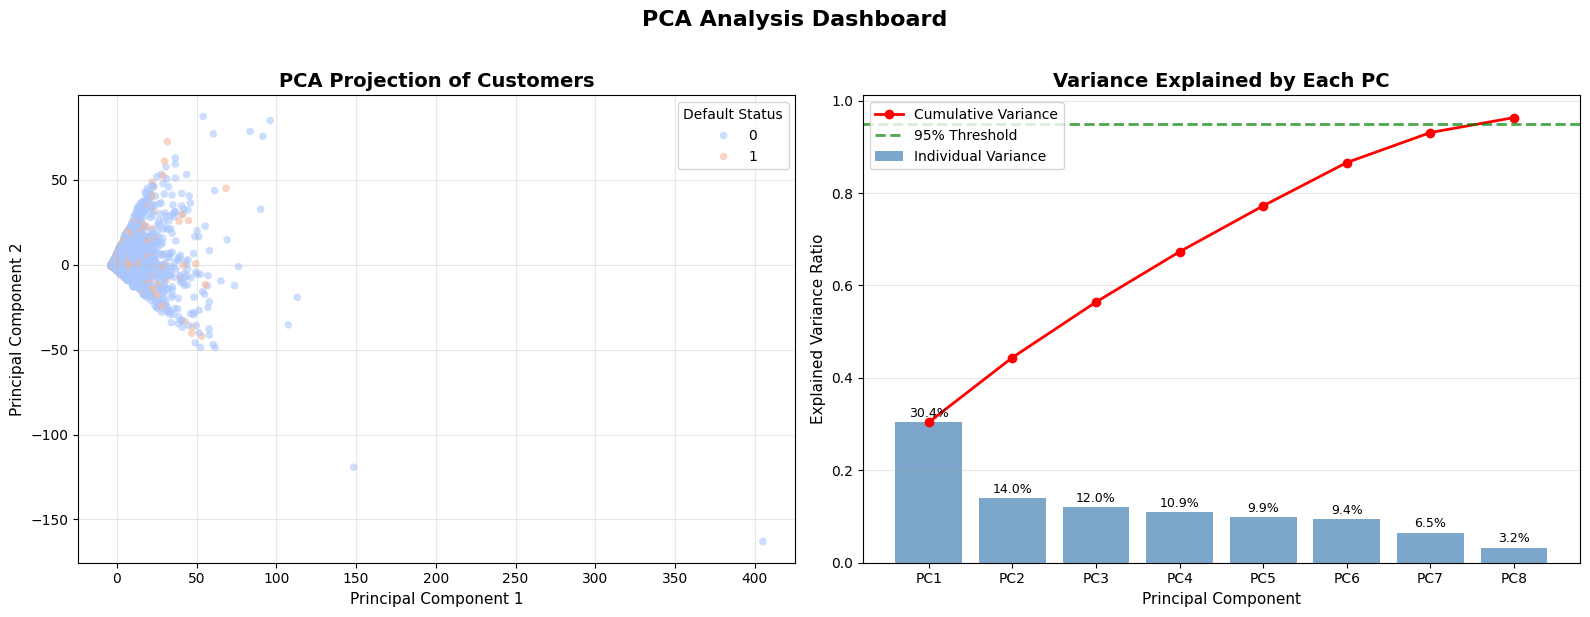

In [47]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('PCA Analysis Dashboard', fontsize=16, fontweight='bold', y=1.02)


# PC1 vs PC2 Projection


pca_vis_df = pd.DataFrame({
    'PC1': X_train_pca[:, 0],
    'PC2': X_train_pca[:, 1],
    'Default': y_train.values
})

sns.scatterplot(
    x='PC1',
    y='PC2',
    hue='Default',
    data=pca_vis_df,
    palette='coolwarm',
    alpha=0.6,
    ax=ax1,
    s=30,
    edgecolor='none'
)

ax1.set_title('PCA Projection of Customers', fontsize=14, fontweight='bold')
ax1.set_xlabel('Principal Component 1', fontsize=11)
ax1.set_ylabel('Principal Component 2', fontsize=11)
ax1.legend(title='Default Status', loc='best', frameon=True)
ax1.grid(alpha=0.3)


# Explained Variance Bar Chart

# Get explained variance ratios
explained_var = pca.explained_variance_ratio_[:optimal_components]
cumulative_var = np.cumsum(explained_var)
x_pos = np.arange(1, optimal_components + 1)

# Create bar chart
bars = ax2.bar(x_pos, explained_var, alpha=0.7, color='steelblue', label='Individual Variance')

# Add cumulative line
ax2.plot(x_pos, cumulative_var, 'ro-', linewidth=2, markersize=6, label='Cumulative Variance')

# Add 95% threshold line
ax2.axhline(y=0.95, color='green', linestyle='--', linewidth=2, alpha=0.7, label='95% Threshold')

# Labels and formatting
ax2.set_xlabel('Principal Component', fontsize=11)
ax2.set_ylabel('Explained Variance Ratio', fontsize=11)
ax2.set_title('Variance Explained by Each PC', fontsize=14, fontweight='bold')
ax2.set_xticks(x_pos)
ax2.set_xticklabels([f'PC{i}' for i in range(1, optimal_components + 1)])
ax2.legend(loc='upper left', frameon=True)
ax2.grid(alpha=0.3, axis='y')

# Add value labels on bars
for i, (bar, var) in enumerate(zip(bars, explained_var)):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{var:.1%}', ha='center', va='bottom', fontsize=9)



plt.tight_layout()
plt.show()

### **PCA Loadings Table**

In [48]:
pca_loadings = pd.DataFrame(
    pca.components_,
    
    columns=X.columns,
    
    index=[
        f'PC{i+1}'
        for i in range(pca.n_components_)
    ]
)

pca_loadings

,Limit_Bal,Gender,Education,Marriage,Age,RPay_stat_sep,RPay_stat_aug,RPay_stat_jul,RPay_stat_jun,RPay_stat_may,...,Bill_amt_jul,Bill_amt_jun,Bill_amt_may,Bill_amt_apr,Pay_amt_sep,Pay_amt_aug,Pay_amt_jul,Pay_amt_jun,Pay_amt_may,Pay_amt_apr
PC1,0.039588,-0.000421,-0.008037,-0.001305,0.005537,-0.019235,-0.015582,-0.012841,-0.005911,-0.002226,...,0.077648,0.083268,0.083699,0.079185,0.386776,0.572151,0.395235,0.333850,0.245496,0.398962
PC2,0.012967,0.000279,-0.003059,-0.000079,0.000455,-0.002055,0.002175,0.003854,-0.005285,-0.006791,...,-0.001807,0.001558,0.002885,0.002055,-0.073779,-0.518623,-0.118624,-0.010116,0.173212,0.824413
PC3,-0.016165,-0.000178,0.004946,0.000419,-0.002016,0.000112,-0.002538,-0.006955,0.010119,0.001588,...,-0.001688,-0.036979,-0.061547,-0.082524,-0.076721,0.555111,-0.400022,-0.476416,-0.387301,0.363955
PC4,0.011147,0.000069,-0.001115,-0.000434,0.002062,-0.001041,0.002502,-0.001723,0.006226,-0.002269,...,0.031494,0.003397,-0.009314,0.048595,-0.114699,0.190827,-0.380225,-0.241031,0.852764,-0.128176
PC5,0.000071,0.000492,-0.000870,-0.001300,-0.000027,-0.004354,-0.003004,-0.006395,0.002690,-0.020083,...,0.002514,-0.042783,0.011974,-0.002945,-0.077422,0.103339,-0.634938,0.752862,-0.103534,-0.001762
PC6,-0.002231,0.000556,0.000831,0.000261,0.000352,0.002331,-0.002945,0.028494,0.017847,0.008511,...,0.032416,0.011518,0.004825,0.004598,0.896017,-0.211899,-0.330600,-0.161711,-0.041728,-0.095774
PC7,-0.011950,-0.009785,0.026896,-0.000269,-0.000084,0.214198,0.267892,0.267503,0.266771,0.256882,...,0.314847,0.321621,0.324945,0.308624,-0.104168,-0.009396,-0.072147,-0.053269,-0.095495,-0.021921
PC8,-0.144303,-0.011328,0.041027,0.016915,-0.032997,0.251046,0.322120,0.345614,0.338542,0.317266,...,-0.252329,-0.248246,-0.242133,-0.223534,0.064231,0.031602,0.067935,0.067668,0.090090,0.043090


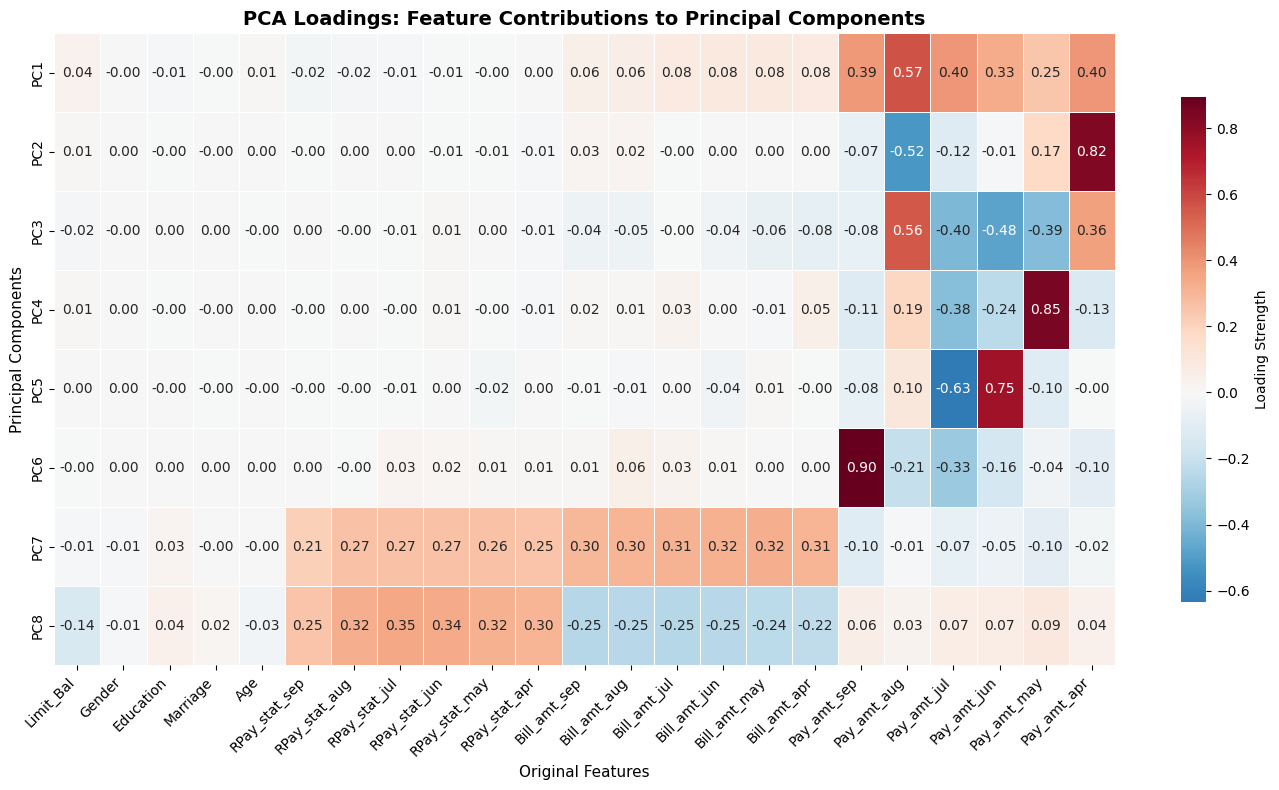

In [49]:
# Heatmap of PCA Loadings
plt.figure(figsize=(14, 8))

# Create heatmap
sns.heatmap(pca_loadings, 
            annot=True, 
            fmt='.2f', 
            cmap='RdBu_r',
            center=0,
            cbar_kws={'label': 'Loading Strength', 'shrink': 0.8},
            linewidths=0.5,
            square=False)

plt.title('PCA Loadings: Feature Contributions to Principal Components', 
          fontsize=14, fontweight='bold')
plt.xlabel('Original Features', fontsize=11)
plt.ylabel('Principal Components', fontsize=11)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

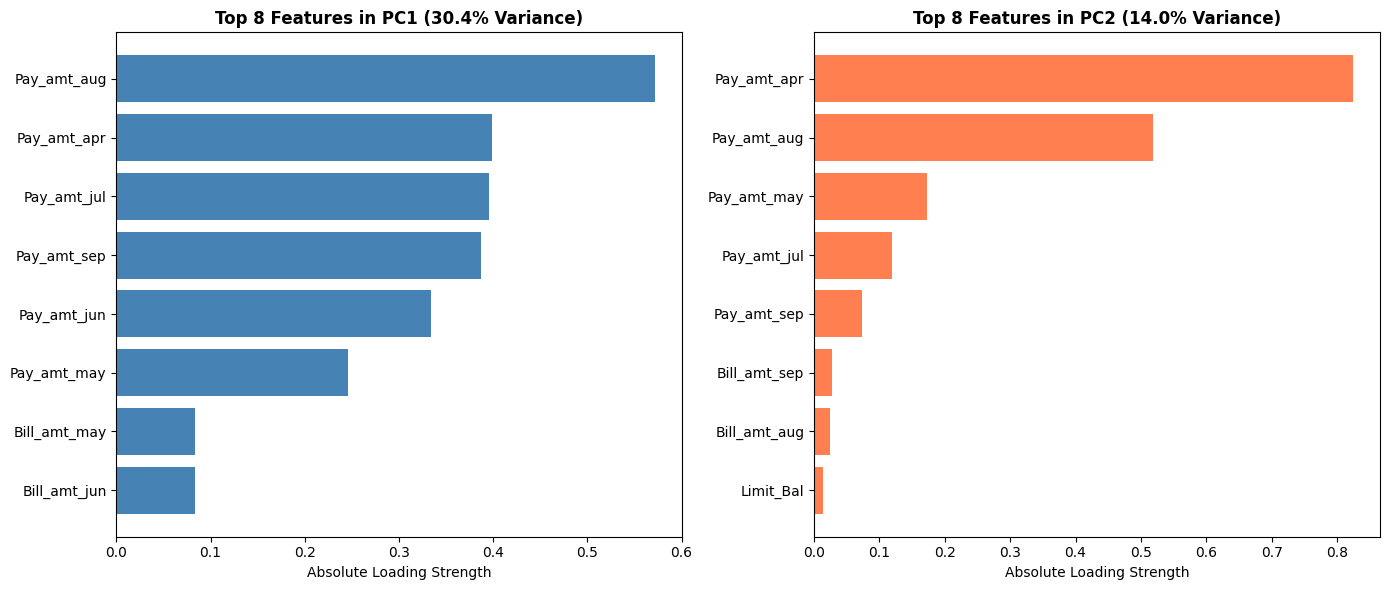

In [50]:
# Show top features for PC1 and PC2
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# PC1 Top Features
pc1_loadings = pca_loadings.loc['PC1'].abs().sort_values(ascending=False).head(8)
axes[0].barh(range(len(pc1_loadings)), pc1_loadings.values, color='steelblue')
axes[0].set_yticks(range(len(pc1_loadings)))
axes[0].set_yticklabels(pc1_loadings.index)
axes[0].set_xlabel('Absolute Loading Strength')
axes[0].set_title('Top 8 Features in PC1 (30.4% Variance)', fontweight='bold')
axes[0].invert_yaxis()

# PC2 Top Features
pc2_loadings = pca_loadings.loc['PC2'].abs().sort_values(ascending=False).head(8)
axes[1].barh(range(len(pc2_loadings)), pc2_loadings.values, color='coral')
axes[1].set_yticks(range(len(pc2_loadings)))
axes[1].set_yticklabels(pc2_loadings.index)
axes[1].set_xlabel('Absolute Loading Strength')
axes[1].set_title('Top 8 Features in PC2 (14.0% Variance)', fontweight='bold')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

# **Saving Processed data for SVM-Modeling Reuse**

## **Save ML Arrays**

In [51]:
np.save(
    '../data/processed/X_train_scaled.npy',
    X_train_scaled
)

np.save(
    '../data/processed/X_test_scaled.npy',
    X_test_scaled
)

np.save(
    '../data/processed/X_train_pca.npy',
    X_train_pca
)

np.save(
    '../data/processed/X_test_pca.npy',
    X_test_pca
)

## **Save Target**

In [52]:
np.save(
    '../data/processed/y_train.npy',
    y_train
)

np.save(
    '../data/processed/y_test.npy',
    y_test
)

## **Saving Artifacts**

In [54]:
import joblib

joblib.dump(
    scaler,
    '../artifacts/scaler.pkl'
)

joblib.dump(
    pca,
    '../artifacts/pca.pkl'
)

['../artifacts/pca.pkl']